In [1]:
import xarray as xr

# Step 1: Load chlorophyll data inside the .SEN3 directory
chl_ds = xr.open_dataset(r"C:/Users/grace/Desktop/S3B_OL_2_WFR____20200524T040216_20200524T040516_20210617T213340_0179_039_161______MAR_R_NT_003.SEN3/chl_oc4me.nc")

# Print data variables
print(chl_ds)


<xarray.Dataset>
Dimensions:        (rows: 4091, columns: 4865)
Dimensions without coordinates: rows, columns
Data variables:
    CHL_OC4ME      (rows, columns) float32 ...
    CHL_OC4ME_err  (rows, columns) float32 ...
Attributes: (12/16)
    title:                  OLCI Level 2 WATER Product, OC4Me Chlorophyll con...
    comment:                 
    netCDF_version:         4.2 of Jul  5 2012 17:07:43 $
    product_name:           S3B_OL_2_WFR____20200524T040216_20200524T040516_2...
    institution:            MAR
    source:                 IPF-OL-2 07.01
    ...                     ...
    resolution:             [ 270 294 ]
    absolute_orbit_number:  10828
    start_time:             2020-05-24T04:02:15.684398Z
    stop_time:              2020-05-24T04:05:15.684398Z
    ac_subsampling_factor:  64
    al_subsampling_factor:  1


In [2]:
# Step 2: Extract chlorophyll-a variable as a NumPy array
import numpy as np

chl = chl_ds['CHL_OC4ME'].values

# Print basic stats to check data
print("Chlorophyll-a shape:", chl.shape)
print("Min:", np.nanmin(chl), "Max:", np.nanmax(chl))


Chlorophyll-a shape: (4091, 4865)
Min: -2.0 Max: 2.0


In [4]:
# Step 3: Load latitude and longitude
geo_ds = xr.open_dataset(r"C:/Users/grace/Desktop/S3B_OL_2_WFR____20200524T040216_20200524T040516_20210617T213340_0179_039_161______MAR_R_NT_003.SEN3/geo_coordinates.nc")

# Extract lat and lon as numpy arrays
lat = geo_ds['latitude'].values
lon = geo_ds['longitude'].values

# Confirm shapes
print("Latitude shape:", lat.shape)
print("Longitude shape:", lon.shape)


Latitude shape: (4091, 4865)
Longitude shape: (4091, 4865)


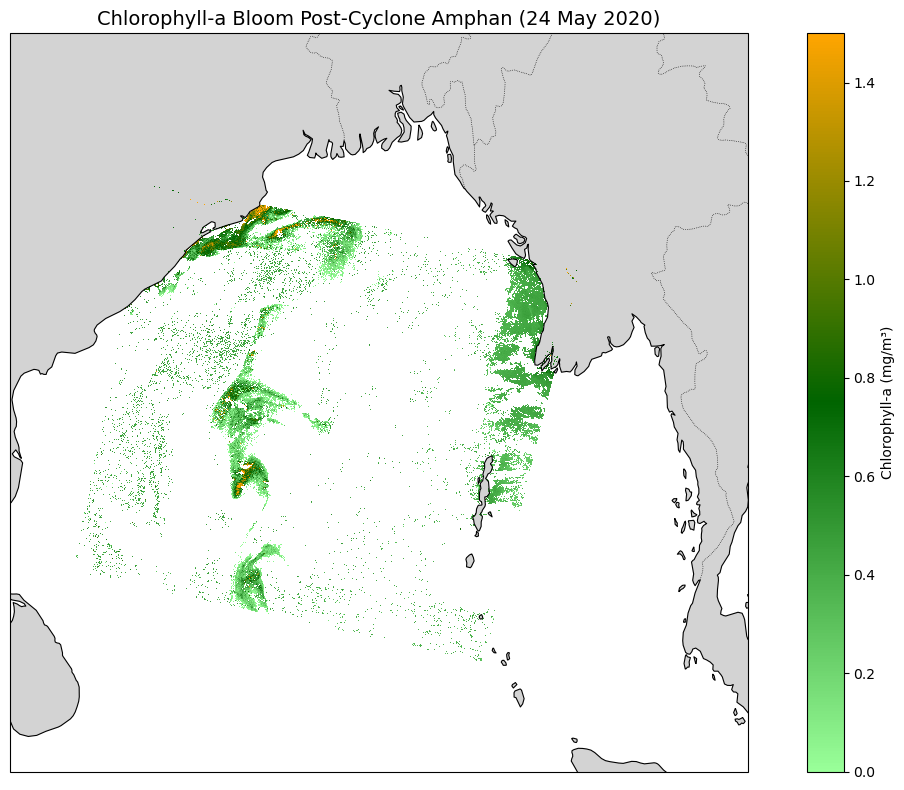

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Step 1: Mask invalid values (negative or extremely high values)
chl_clean = np.ma.masked_where((chl < 0) | (chl > 20), chl)

# Step 2: Custom colormap: # light green → dark green → orange
bloom_cmap = LinearSegmentedColormap.from_list(
    "green_to_orange",
    ["#99ff99", "#006400", "#FFA500"]  # light green → dark green → orange
)
# Step 3: Set up plot with Cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set focus area (Bay of Bengal)
ax.set_extent([80, 100, 5, 25], crs=ccrs.PlateCarree())

# Add land, coastlines, borders
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Step 4: Plot chlorophyll data
mesh = ax.pcolormesh(
    lon, lat, chl_clean,
    cmap=bloom_cmap,
    shading='auto',
    vmin=0, vmax=1.50,
    transform=ccrs.PlateCarree()
)

# Step 5: Add colorbar and labels
plt.colorbar(mesh, label="Chlorophyll-a (mg/m³)")
plt.title("Chlorophyll-a Bloom Post-Cyclone Amphan (24 May 2020)", fontsize=14)
plt.tight_layout()
# Save the figure
plt.savefig("chlorophyll_map.png", dpi=300, bbox_inches='tight')

plt.show()
